In [11]:
# Install required packages if not already installed
try:
    import umap
except ImportError:
    print("Installing umap-learn...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "umap-learn"])
    import umap
    print("umap-learn installed successfully!")


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


In [13]:
# Define the methods and their corresponding directories
methods = {
    'Real': 'real',
    'DeepHCS': 'deephcs', 
    'Pix2Pix': 'pix2pix',
    'UNet': 'unet',
    'ResCellDM': 'rescellDM',
    'ResCellDM_Distill': 'rescellDM_Distill'
}

data_types = ['Cells', 'Cytoplasm', 'Nuclei']

# Base directory
base_dir = '../Cell_Profiler/cell_profiler_results/'

print("Available methods:")
for method_name, folder_name in methods.items():
    path = os.path.join(base_dir, folder_name)
    if os.path.exists(path):
        print(f"✓ {method_name} ({folder_name})")
    else:
        print(f"✗ {method_name} ({folder_name}) - Directory not found")


Available methods:
✓ Real (real)
✓ DeepHCS (deephcs)
✓ Pix2Pix (pix2pix)
✓ UNet (unet)
✓ ResCellDM (rescellDM)
✓ ResCellDM_Distill (rescellDM_Distill)


In [14]:
def load_and_preprocess_data(data_type):
    """
    Load and preprocess data for a specific data type (Cells, Cytoplasm, or Nuclei)
    """
    all_data = []
    all_labels = []
    
    for method_name, folder_name in methods.items():
        file_path = os.path.join(base_dir, folder_name, f'{data_type}.csv')
        
        if os.path.exists(file_path):
            print(f"Loading {method_name} {data_type} data...")
            
            # Load data in chunks to handle large files
            chunks = []
            chunk_size = 10000
            
            for chunk in pd.read_csv(file_path, chunksize=chunk_size):
                chunks.append(chunk)
            
            df = pd.concat(chunks, ignore_index=True)
            print(f"  Loaded {len(df)} rows")
            
            # Remove non-numeric columns (ImageNumber, ObjectNumber, etc.)
            numeric_columns = df.select_dtypes(include=[np.number]).columns
            numeric_columns = [col for col in numeric_columns if col not in ['ImageNumber', 'ObjectNumber']]
            
            df_numeric = df[numeric_columns]
            
            # Handle missing values
            df_numeric = df_numeric.dropna()
            
            # Sample data if too large (for computational efficiency)
            if len(df_numeric) > 5000:
                df_numeric = df_numeric.sample(n=5000, random_state=42)
                print(f"  Sampled down to {len(df_numeric)} rows")
            
            all_data.append(df_numeric)
            all_labels.extend([method_name] * len(df_numeric))
            
        else:
            print(f"Warning: {file_path} not found")
    
    if not all_data:
        raise ValueError(f"No data found for {data_type}")
    
    # Combine all data
    combined_data = pd.concat(all_data, ignore_index=True)
    
    # Get common columns across all methods
    common_columns = all_data[0].columns
    for df in all_data[1:]:
        common_columns = common_columns.intersection(df.columns)
    
    combined_data = combined_data[common_columns]
    
    print(f"Final dataset shape: {combined_data.shape}")
    print(f"Number of features: {len(common_columns)}")
    
    return combined_data, all_labels, common_columns


In [15]:
def perform_umap_analysis(data, labels, data_type, n_components=2, n_neighbors=15, min_dist=0.1, random_state=42):
    """
    Perform UMAP analysis on the data
    """
    print(f"\nPerforming UMAP analysis for {data_type}...")
    
    # Standardize the data
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    
    # Apply PCA for dimensionality reduction if needed (optional for UMAP but can speed things up)
    if data_scaled.shape[1] > 100:
        print(f"Applying PCA first (reducing from {data_scaled.shape[1]} to 100 dimensions)")
        pca = PCA(n_components=100, random_state=random_state)
        data_scaled = pca.fit_transform(data_scaled)
        print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.sum():.3f}")
    
    # Perform UMAP
    print(f"Running UMAP with n_neighbors={n_neighbors}, min_dist={min_dist}...")
    reducer = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors, 
                       min_dist=min_dist, random_state=random_state, verbose=True)
    umap_results = reducer.fit_transform(data_scaled)
    
    return umap_results


In [16]:
def show_color_legend():
    """
    Display the color mapping for methods
    """
    methods_list = ['Real', 'DeepHCS', 'Pix2Pix', 'UNet', 'ResCellDM', 'ResCellDM_Distill']
    distinct_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33']
    
    print("Color mapping for methods:")
    print("=" * 30)
    for method, color in zip(methods_list, distinct_colors):
        print(f"{method:20} -> {color}")
    print("=" * 30)

# Show the color mapping
show_color_legend()


Color mapping for methods:
Real                 -> #e41a1c
DeepHCS              -> #377eb8
Pix2Pix              -> #4daf4a
UNet                 -> #984ea3
ResCellDM            -> #ff7f00
ResCellDM_Distill    -> #ffff33


In [17]:
def plot_umap_results(umap_results, labels, data_type, save_path=None, max_points_per_method=300):
    """
    Plot UMAP results with method labels
    """
    plt.figure(figsize=(12, 8))
    
    # Create a more distinguishable color palette
    unique_methods = sorted(list(set(labels)))
    # Use distinct colors that are easier to distinguish
    distinct_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33', '#a65628', '#f781bf']
    colors = distinct_colors[:len(unique_methods)]
    color_map = dict(zip(unique_methods, colors))
    
    # Create arrays for sampling
    umap_array = np.array(umap_results)
    labels_array = np.array(labels)
    
    # Plot each method with sampling for better visualization
    for method in unique_methods:
        mask = labels_array == method
        method_points = umap_array[mask]
        
        # Sample points if there are too many
        if len(method_points) > max_points_per_method:
            indices = np.random.choice(len(method_points), max_points_per_method, replace=False)
            method_points = method_points[indices]
        
        plt.scatter(method_points[:, 0], method_points[:, 1], 
                   c=color_map[method], label=method, alpha=0.7, s=25, edgecolors='white', linewidth=0.3)
    
    plt.xlabel('UMAP Component 1', fontsize=12)
    plt.ylabel('UMAP Component 2', fontsize=12)
    plt.title(f'UMAP Analysis of {data_type} Morphological Features', fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fancybox=True, shadow=True)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    plt.show()
    
    # Print summary statistics
    print(f"\n{data_type} UMAP Summary:")
    for method in unique_methods:
        count = sum(1 for label in labels if label == method)
        percentage = count / len(labels) * 100
        print(f"  {method}: {count} samples ({percentage:.1f}%)")



PROCESSING CELLS DATA
Loading Real Cells data...
  Loaded 4279 rows
Loading DeepHCS Cells data...
  Loaded 4244 rows
Loading Pix2Pix Cells data...
  Loaded 4365 rows
Loading UNet Cells data...
  Loaded 4282 rows
Loading ResCellDM Cells data...
  Loaded 4273 rows
Loading ResCellDM_Distill Cells data...
  Loaded 4286 rows
Final dataset shape: (25729, 1180)
Number of features: 1180

Performing UMAP analysis for Cells...
Applying PCA first (reducing from 1180 to 100 dimensions)
PCA explained variance ratio: 0.937
Running UMAP with n_neighbors=15, min_dist=0.1...
UMAP(n_jobs=1, random_state=42, verbose=True)
Sun Jun 29 17:21:25 2025 Construct fuzzy simplicial set
Sun Jun 29 17:21:25 2025 Finding Nearest Neighbors
Sun Jun 29 17:21:25 2025 Building RP forest with 13 trees
Sun Jun 29 17:21:25 2025 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Sun Jun 29 17:21:27 2025 Finished Nearest Neighbor Search
Sun Jun 29 17

Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Sun Jun 29 17:21:38 2025 Finished embedding
Plot saved to results\umap_cells_analysis.png


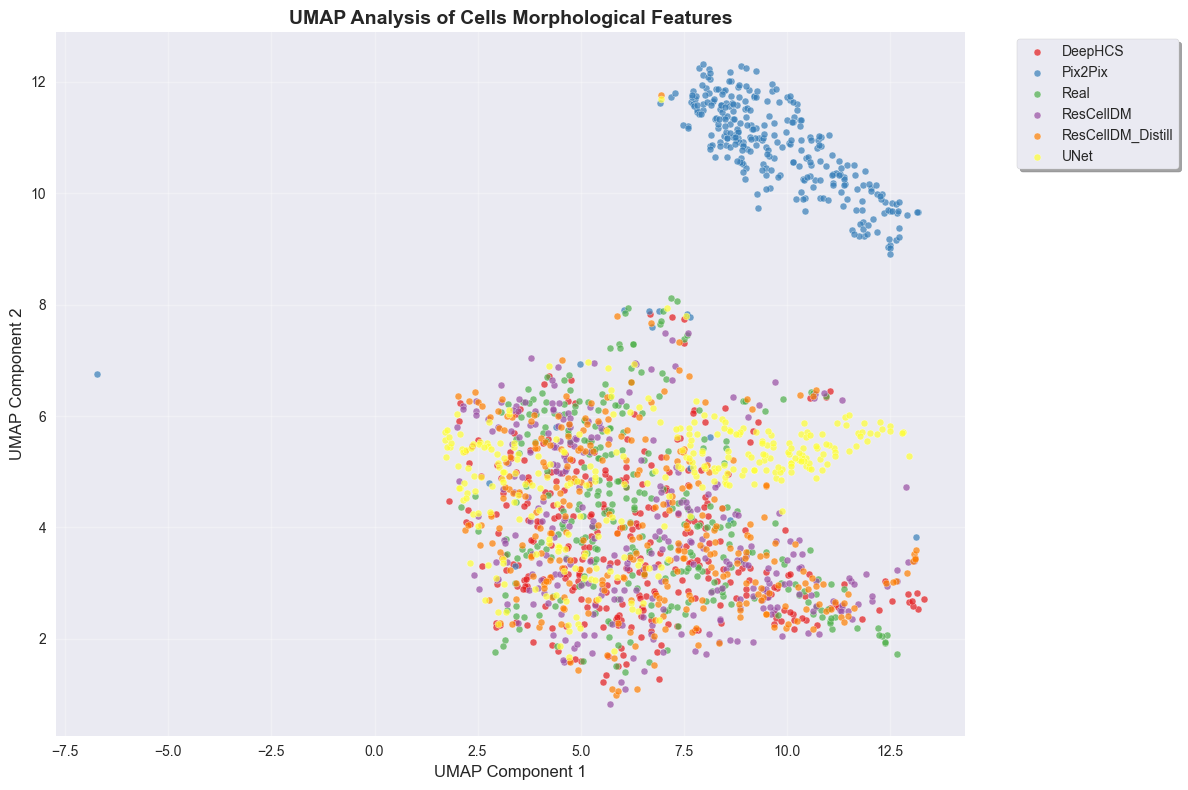


Cells UMAP Summary:
  DeepHCS: 4244 samples (16.5%)
  Pix2Pix: 4365 samples (17.0%)
  Real: 4279 samples (16.6%)
  ResCellDM: 4273 samples (16.6%)
  ResCellDM_Distill: 4286 samples (16.7%)
  UNet: 4282 samples (16.6%)

PROCESSING CYTOPLASM DATA
Loading Real Cytoplasm data...
  Loaded 4279 rows
Loading DeepHCS Cytoplasm data...
  Loaded 4244 rows
Loading Pix2Pix Cytoplasm data...
  Loaded 4365 rows
Loading UNet Cytoplasm data...
  Loaded 4282 rows
Loading ResCellDM Cytoplasm data...
  Loaded 4273 rows
Loading ResCellDM_Distill Cytoplasm data...
  Loaded 4286 rows
Final dataset shape: (25729, 1165)
Number of features: 1165

Performing UMAP analysis for Cytoplasm...
Applying PCA first (reducing from 1165 to 100 dimensions)
PCA explained variance ratio: 0.929
Running UMAP with n_neighbors=15, min_dist=0.1...
UMAP(n_jobs=1, random_state=42, verbose=True)
Sun Jun 29 17:21:48 2025 Construct fuzzy simplicial set
Sun Jun 29 17:21:48 2025 Finding Nearest Neighbors
Sun Jun 29 17:21:48 2025 Build

Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Sun Jun 29 17:22:01 2025 Finished embedding
Plot saved to results\umap_cytoplasm_analysis.png


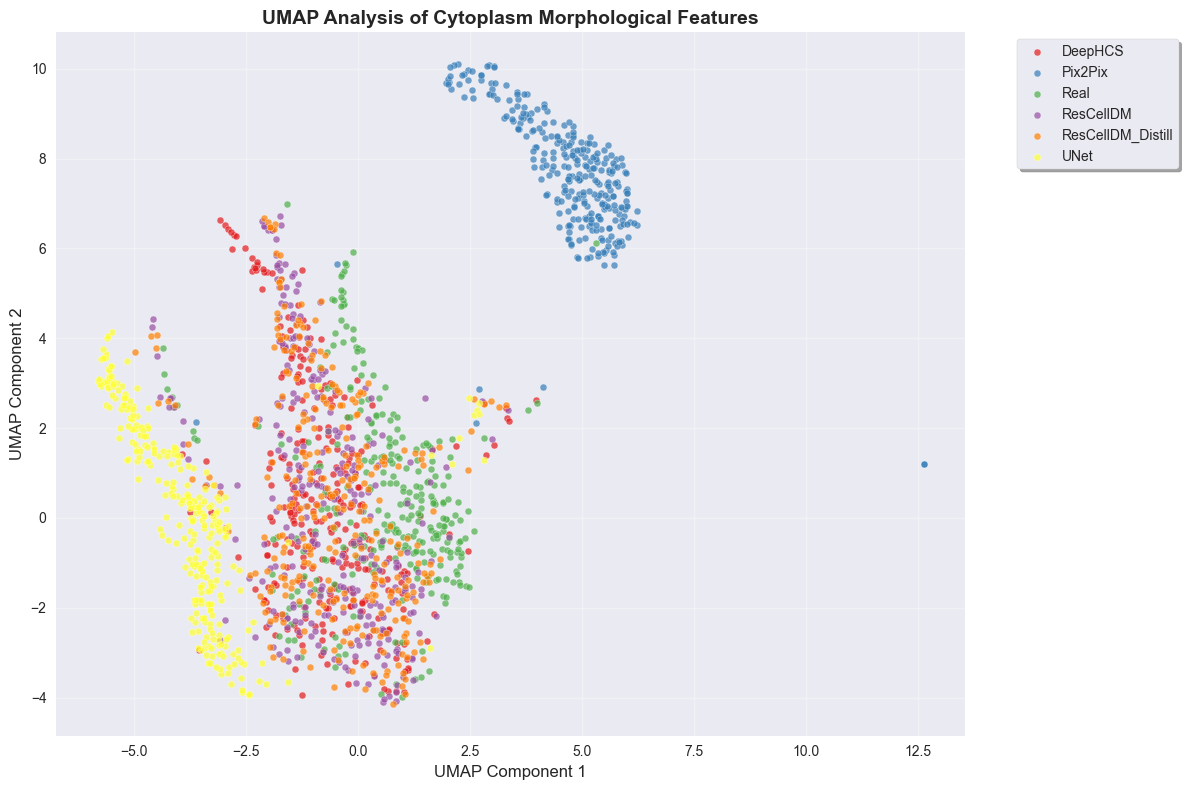


Cytoplasm UMAP Summary:
  DeepHCS: 4244 samples (16.5%)
  Pix2Pix: 4365 samples (17.0%)
  Real: 4279 samples (16.6%)
  ResCellDM: 4273 samples (16.6%)
  ResCellDM_Distill: 4286 samples (16.7%)
  UNet: 4282 samples (16.6%)

PROCESSING NUCLEI DATA
Loading Real Nuclei data...
  Loaded 4279 rows
Loading DeepHCS Nuclei data...
  Loaded 4244 rows
Loading Pix2Pix Nuclei data...
  Loaded 4365 rows
Loading UNet Nuclei data...
  Loaded 4282 rows
Loading ResCellDM Nuclei data...
  Loaded 4273 rows
Loading ResCellDM_Distill Nuclei data...
  Loaded 4286 rows
Final dataset shape: (25723, 1173)
Number of features: 1173

Performing UMAP analysis for Nuclei...
Applying PCA first (reducing from 1173 to 100 dimensions)
PCA explained variance ratio: 0.921
Running UMAP with n_neighbors=15, min_dist=0.1...
UMAP(n_jobs=1, random_state=42, verbose=True)
Sun Jun 29 17:22:11 2025 Construct fuzzy simplicial set
Sun Jun 29 17:22:11 2025 Finding Nearest Neighbors
Sun Jun 29 17:22:11 2025 Building RP forest with 1

Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Sun Jun 29 17:22:24 2025 Finished embedding
Plot saved to results\umap_nuclei_analysis.png


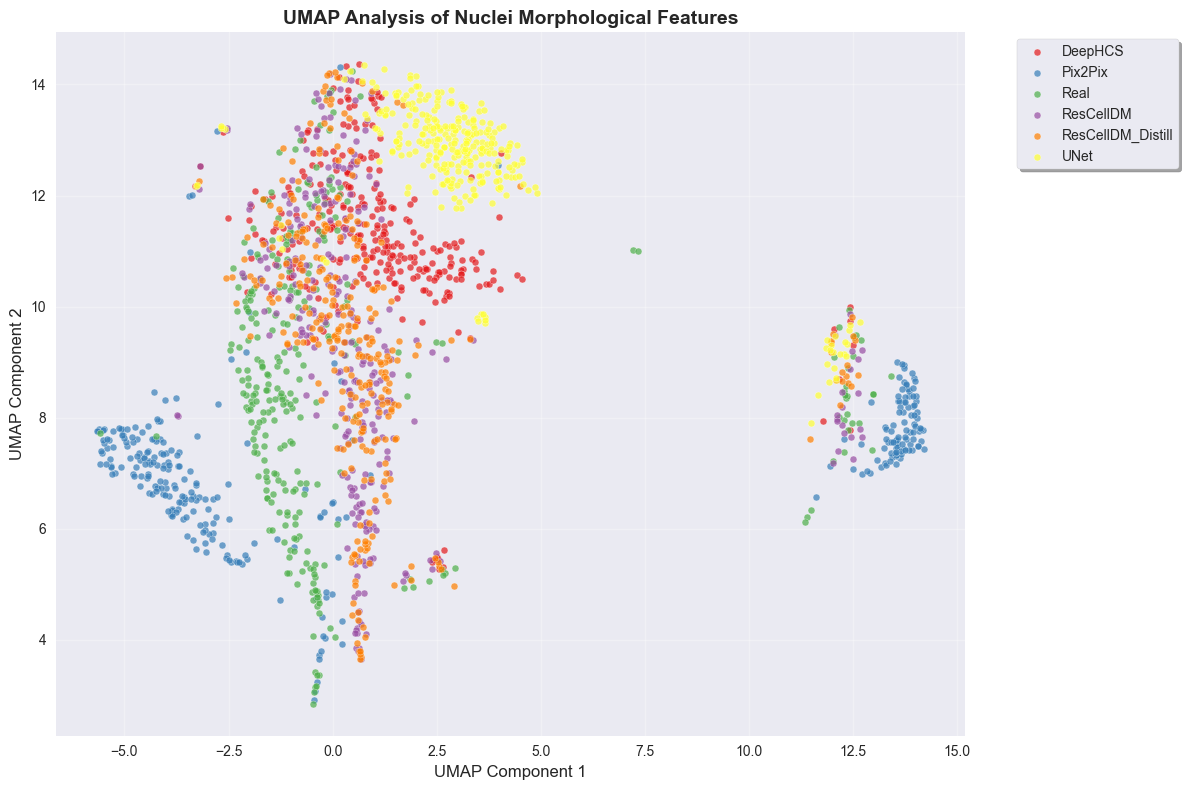


Nuclei UMAP Summary:
  DeepHCS: 4244 samples (16.5%)
  Pix2Pix: 4365 samples (17.0%)
  Real: 4273 samples (16.6%)
  ResCellDM: 4273 samples (16.6%)
  ResCellDM_Distill: 4286 samples (16.7%)
  UNet: 4282 samples (16.6%)


In [18]:
# Create results directory if it doesn't exist
results_dir = 'results'
os.makedirs(results_dir, exist_ok=True)

# Store all results
all_results = {}

for data_type in data_types:
    print(f"\n{'='*60}")
    print(f"PROCESSING {data_type.upper()} DATA")
    print(f"{'='*60}")
    
    try:
        # Load and preprocess data
        data, labels, features = load_and_preprocess_data(data_type)
        
        # Perform UMAP analysis
        umap_results = perform_umap_analysis(data, labels, data_type)
        
        # Plot results
        save_path = os.path.join(results_dir, f'umap_{data_type.lower()}_analysis.png')
        plot_umap_results(umap_results, labels, data_type, save_path)
        
        # Store results
        all_results[data_type] = {
            'umap_results': umap_results,
            'labels': labels,
            'features': features,
            'data_shape': data.shape
        }
        
    except Exception as e:
        print(f"Error processing {data_type}: {str(e)}")
        continue


Combined plot saved to results\umap_combined_analysis.png


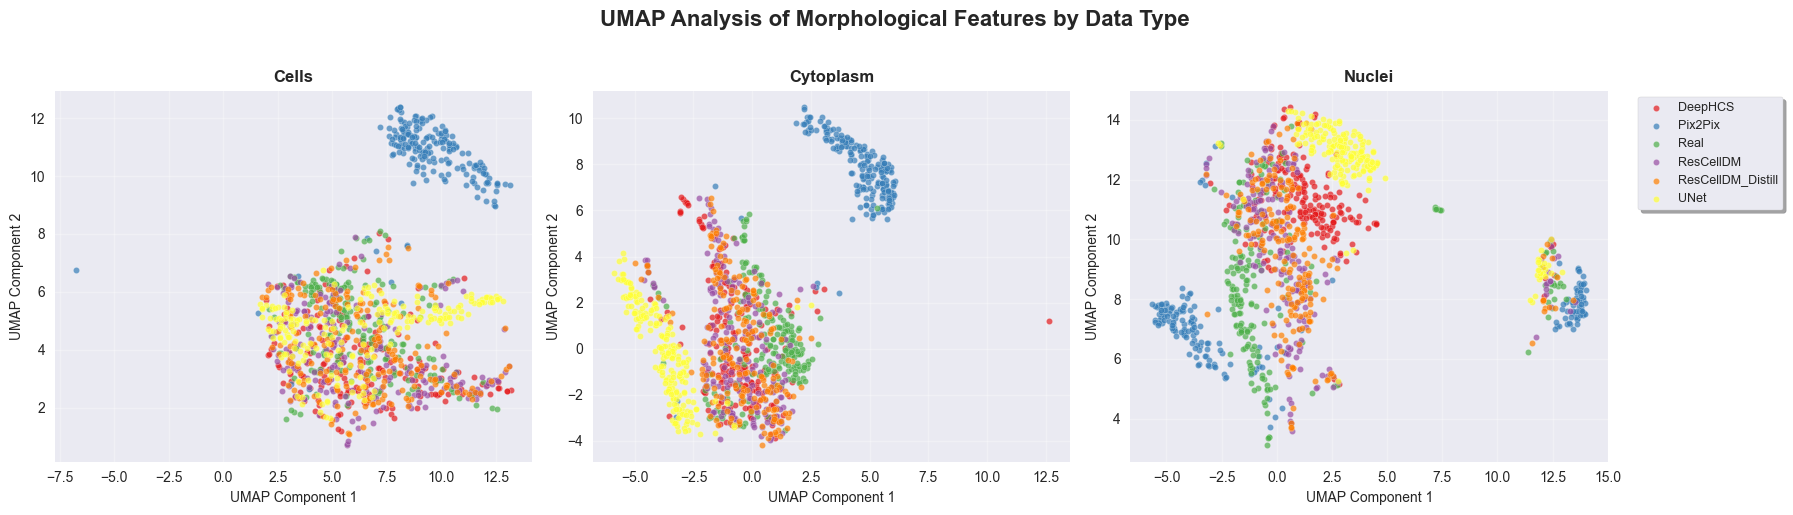

In [24]:
# Create a combined plot with all three data types
method_name ={
    'Real': 'Real',
    'DeepHCS': 'DeepHCS', 
    'Pix2Pix': 'Pix2Pix',
    'UNet': 'U-Net',
    'ResCellDM': 'ResCellDM',
    'ResCellDM_Distill': 'Consistency Distilled CellResDM'
}
if len(all_results) > 0:
    fig, axes = plt.subplots(1, len(all_results), figsize=(6*len(all_results), 5))
    
    if len(all_results) == 1:
        axes = [axes]
    
    # Use the same distinct color palette across all plots
    all_unique_methods = set()
    for results in all_results.values():
        all_unique_methods.update(results['labels'])
    all_unique_methods = sorted(list(all_unique_methods))
    
    distinct_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33', '#a65628', '#f781bf']
    colors = distinct_colors[:len(all_unique_methods)]
    global_color_map = dict(zip(all_unique_methods, colors))
    
    max_points_per_method = 200  # Fewer points for combined plot
    
    for idx, (data_type, results) in enumerate(all_results.items()):
        ax = axes[idx]
        
        umap_results = results['umap_results']
        labels = results['labels']
        
        # Convert to arrays for easier manipulation
        umap_array = np.array(umap_results)
        labels_array = np.array(labels)
        
        # Plot each method with sampling
        for method in sorted(set(labels)):
            mask = labels_array == method
            method_points = umap_array[mask]
            
            # Sample points if there are too many
            if len(method_points) > max_points_per_method:
                indices = np.random.choice(len(method_points), max_points_per_method, replace=False)
                method_points = method_points[indices]
            
            ax.scatter(method_points[:, 0], method_points[:, 1], 
                      c=global_color_map[method], label=method, alpha=0.7, s=20, 
                      edgecolors='white', linewidth=0.2)
        
        ax.set_xlabel('UMAP Component 1', fontsize=10)
        ax.set_ylabel('UMAP Component 2', fontsize=10)
        ax.set_title(f'{data_type}', fontweight='bold', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # Only show legend on the last plot
        if idx == len(all_results) - 1:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, 
                     fancybox=True, shadow=True, fontsize=9)
    
    plt.suptitle('UMAP Analysis of Morphological Features by Data Type', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save combined plot
    combined_save_path = os.path.join(results_dir, 'umap_combined_analysis.png')
    plt.savefig(combined_save_path, dpi=300, bbox_inches='tight')
    print(f"Combined plot saved to {combined_save_path}")
    
    plt.show()


In [9]:
# Summary statistics
print("\n" + "="*80)
print("ANALYSIS SUMMARY")
print("="*80)

for data_type, results in all_results.items():
    print(f"\n{data_type}:")
    print(f"  Data shape: {results['data_shape']}")
    print(f"  Number of features: {len(results['features'])}")
    print(f"  Total samples: {len(results['labels'])}")
    
    # Method distribution
    method_counts = {}
    for label in results['labels']:
        method_counts[label] = method_counts.get(label, 0) + 1
    
    print("  Method distribution:")
    for method, count in sorted(method_counts.items()):
        percentage = count / len(results['labels']) * 100
        print(f"    {method}: {count} samples ({percentage:.1f}%)")

print(f"\nAll plots saved in: {os.path.abspath(results_dir)}")



ANALYSIS SUMMARY

Cells:
  Data shape: (25729, 1180)
  Number of features: 1180
  Total samples: 25729
  Method distribution:
    DeepHCS: 4244 samples (16.5%)
    Pix2Pix: 4365 samples (17.0%)
    Real: 4279 samples (16.6%)
    ResCellDM: 4273 samples (16.6%)
    ResCellDM_Distill: 4286 samples (16.7%)
    UNet: 4282 samples (16.6%)

Cytoplasm:
  Data shape: (25729, 1165)
  Number of features: 1165
  Total samples: 25729
  Method distribution:
    DeepHCS: 4244 samples (16.5%)
    Pix2Pix: 4365 samples (17.0%)
    Real: 4279 samples (16.6%)
    ResCellDM: 4273 samples (16.6%)
    ResCellDM_Distill: 4286 samples (16.7%)
    UNet: 4282 samples (16.6%)

Nuclei:
  Data shape: (25723, 1173)
  Number of features: 1173
  Total samples: 25723
  Method distribution:
    DeepHCS: 4244 samples (16.5%)
    Pix2Pix: 4365 samples (17.0%)
    Real: 4273 samples (16.6%)
    ResCellDM: 4273 samples (16.6%)
    ResCellDM_Distill: 4286 samples (16.7%)
    UNet: 4282 samples (16.6%)

All plots saved in: